# Analyses

Isaac T. Petersen, Zachary Demko, and Megan Schumer  
June 16, 2026

# Intro

# Preamble

## Install Libraries

In [ ]:
#install.packages("remotes")
#remotes::install_github("DevPsyLab/petersenlab")

## Load Libraries

In [ ]:
#| message: false
#| warning: false

library("petersenlab") #located here: https://github.com/DevPsyLab/petersenlab
library("tidyverse")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

## Load Data

In [ ]:
longitudinalStudies <- read_csv("../Data/longitudinalStudies.csv") #read_csv("./Data/longitudinalStudies.csv")

Rows: 45 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): study, studyLabel, designType, sampleType, country, continent
dbl (8): sampleSize, yearStart, yearMostRecentAssessment, yearEnd, ageStartM...
lgl (3): prenatalRecruitment, active, interventionPrevention

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Rows: 19 Columns: 20
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (12): sample, sampleLabel, study, year, studyLabel, measurementOccasions...
dbl  (6): sampleSize, ageStartMin, ageStartMax, ageEndMin, ageEndMax, maxTim...
lgl  (2): registry, developmentalScaling

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

# Plots

## Longitudinal Studies

In [ ]:
# prepare data for plot
longitudinalStudies_plotData <- bind_rows(

  # ---- start cross-section ----
  longitudinalStudies %>%
    mutate(
      segment_group = "cross-section",
      segment_type = "start_crossSection",
      ageStart = ageStartMin,
      ageEnd = ageStartMax
    ) %>%
    select(study, studyLabel, ageStart, ageEnd, segment_group, segment_type),

  # ---- core (ONLY if true longitudinal cohort span exists) ----
  longitudinalStudies %>%
    mutate(has_cor = ageStartMax < ageEndMin) %>%
    filter(has_cor) %>%
    mutate(
      segment_group = "core",
      segment_type = "core",
      ageStart = ageStartMax,
      ageEnd = ageEndMin
    ) %>%
    select(study, studyLabel, ageStart, ageEnd, segment_group, segment_type),

  # ---- end cross-section ----
  longitudinalStudies %>%
    mutate(
      segment_group = "cross-section",
      segment_type = "end_crossSection",
      ageStart = ageEndMin,
      ageEnd = ageEndMax
    ) %>%
    select(study, studyLabel, ageStart, ageEnd, segment_group, segment_type)
)

# Merge active status
longitudinalStudies_plotData <- longitudinalStudies_plotData %>%
  left_join(
    longitudinalStudies %>% select(study, active),
    by = c("study")
  )

# Order studies for plot
study_order <- longitudinalStudies %>%
  arrange(ageEndMax, ageStartMin) %>%
  pull(studyLabel)

longitudinalStudies_plotData <- longitudinalStudies_plotData %>%
  mutate(studyLabelFactor = factor(studyLabel, levels = study_order))

# Prenatal enrollment
prenatal_df <- longitudinalStudies %>%
  filter(prenatalRecruitment == TRUE) %>%
  mutate(
    age = 0,
    studyLabelFactor = factor(studyLabel, levels = study_order)
  )

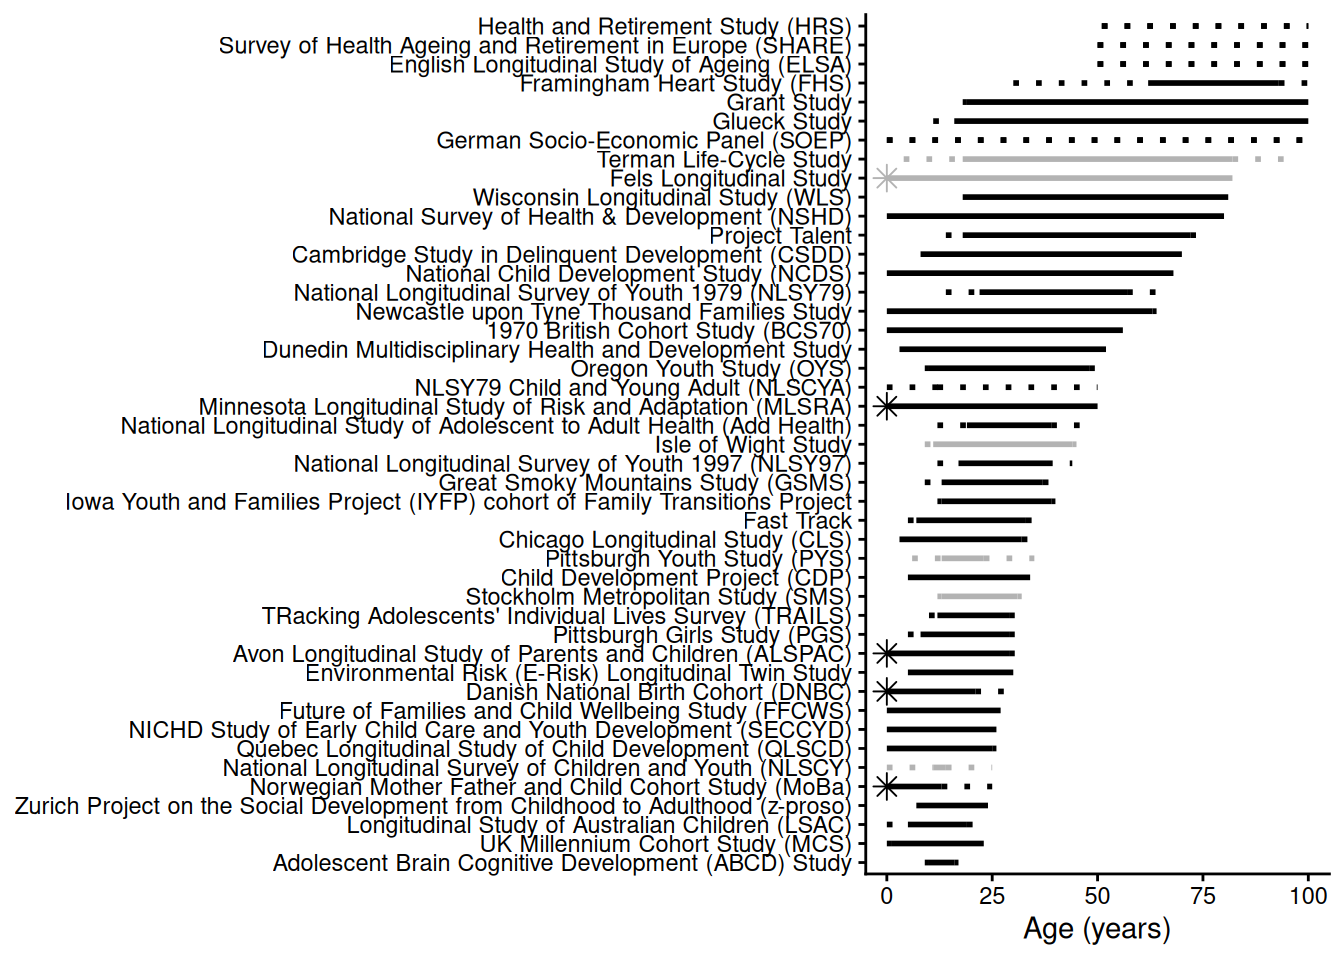

In [ ]:
#| label: fig-longitudinalstudies
#| fig-cap: "(Approximate) ages spanned by various lengthy longitudinal studies, as of this writing. The list of longitudinal studies is not exhaustive. Studies that are no longer active are shown in gray. Solid lines reflect fully longitudinal spans (i.e., the same individuals were followed over time). Dotted lines reflect ages assessed cross-sectionally—even if some participants may have been followed longitudinally. For instance, if a study recruited 5–10-year-old children and followed each child for 20 years, the study would have dotted lines from ages 5–10 and from ages 25–30. Studies shown entirely with dotted lines assessed their full age range cross-sectionally but still included longitudinal follow-up of some participants. A star at age 0 represents that participants were enrolled before birth and the study included prenatal assessments. Ages spanned reflect ages when assessments were collected directly from participants; ages spanned do not include links to registry data (e.g., birth records, offending records). Age was truncated at 100; thus, age 100 indicates that participants were followed into their 90s (or until death)."
#| fig-alt: "(Approximate) ages spanned by various lengthy longitudinal studies, as of this writing. The list of longitudinal studies is not exhaustive. Studies that are no longer active are shown in gray. Solid lines reflect fully longitudinal spans (i.e., the same individuals were followed over time). Dotted lines reflect ages assessed cross-sectionally—even if some participants may have been followed longitudinally. For instance, if a study recruited 5–10-year-old children and followed each child for 20 years, the study would have dotted lines from ages 5–10 and from ages 25–30. Studies shown entirely with dotted lines assessed their full age range cross-sectionally but still included longitudinal follow-up of some participants. A star at age 0 represents that participants were enrolled before birth and the study included prenatal assessments. Ages spanned reflect ages when assessments were collected directly from participants; ages spanned do not include links to registry data (e.g., birth records, offending records). Age was truncated at 100; thus, age 100 indicates that participants were followed into their 90s (or until death)."

plot_longitudinalStudies <- ggplot2::ggplot(
  data = longitudinalStudies_plotData,
  mapping = aes(
    y = studyLabelFactor
  )
) +
  geom_segment(
    aes(
      x = ageStart,
      xend = ageEnd,
      yend = studyLabelFactor,
      linetype = segment_group,
      color = active
    ),
    linewidth = 1
  ) +
  scale_linetype_manual(
    values = c(
      "cross-section" = "dotted",
      "core" = "solid"
    ),
    guide = "none"
  ) +
  scale_color_manual(
    values = c(
      "TRUE" = "black",
      "FALSE" = "gray70"
    ),
    guide = "none"
  ) +
  geom_point(
    data = prenatal_df,
    aes(
      x = age,
      y = studyLabelFactor,
      color = active
    ),
    shape = 8,
    size = 3
  ) +
  labs(
    x = "Age (years)",
    y = NULL
  ) +
  theme_classic()

plot_longitudinalStudies

## Longitudinal Externalizing Studies

In [ ]:
longitudinalExternalizingStudies_plotData <- bind_rows(

  # start cross-sectional span
  longitudinalExternalizingStudies %>%
    mutate(
      segment_group = "cross-section",
      ageStart = ageStartMin,
      ageEnd = ageStartMax
    ) %>%
    select(
      sample,
      sampleLabel,
      study,
      studyLabel,
      ageStart,
      ageEnd,
      segment_group
    ),

  # core longitudinal span
  longitudinalExternalizingStudies %>%
    mutate(has_core = ageStartMax < ageEndMin) %>%
    filter(has_core) %>%
    mutate(
      segment_group = "core",
      ageStart = ageStartMax,
      ageEnd = ageEndMin
    ) %>%
    select(
      sample,
      sampleLabel,
      study,
      studyLabel,
      ageStart,
      ageEnd,
      segment_group
    ),

  # end cross-sectional span
  longitudinalExternalizingStudies %>%
    mutate(
      segment_group = "cross-section",
      ageStart = ageEndMin,
      ageEnd = ageEndMax
    ) %>%
    select(
      sample,
      sampleLabel,
      study,
      studyLabel,
      ageStart,
      ageEnd,
      segment_group
    )
)

# Merge registry classification
longitudinalExternalizingStudies_plotData <- longitudinalExternalizingStudies_plotData %>%
  left_join(
    longitudinalExternalizingStudies %>%
      select(study, registry),
    by = "study"
  )

# Order studies for plot
longitudinalExternalizingStudies_order <- longitudinalExternalizingStudies %>%
  arrange(ageEndMax, ageStartMin) %>%
  pull(studyLabel)

longitudinalExternalizingStudies_plotData <- longitudinalExternalizingStudies_plotData %>%
  mutate(
    studyLabelFactor = factor(
      studyLabel,
      levels = longitudinalExternalizingStudies_order
    )
  )

# Measurement occasions
longitudinalExternalizingStudies_measurementOccasions <- longitudinalExternalizingStudies %>%
  filter(!is.na(measurementOccasions)) %>%
  separate_rows(
    measurementOccasions,
    sep = ";"
  ) %>%
  mutate(
    measurementOccasions = as.numeric(
      str_trim(measurementOccasions)
    ),
    studyLabelFactor = factor(
      studyLabel,
      levels = longitudinalExternalizingStudies_order
    ),
    y = as.numeric(studyLabelFactor) + 0.2
  )

# Label positions
longitudinalExternalizingStudies_sampleLabels <- longitudinalExternalizingStudies %>%
  mutate(
    studyLabelFactor = factor(
      studyLabel,
      levels = longitudinalExternalizingStudies_order
    ),
    label_x = (ageStartMin + ageEndMax) / 2,
    label_y = as.numeric(studyLabelFactor)
  )

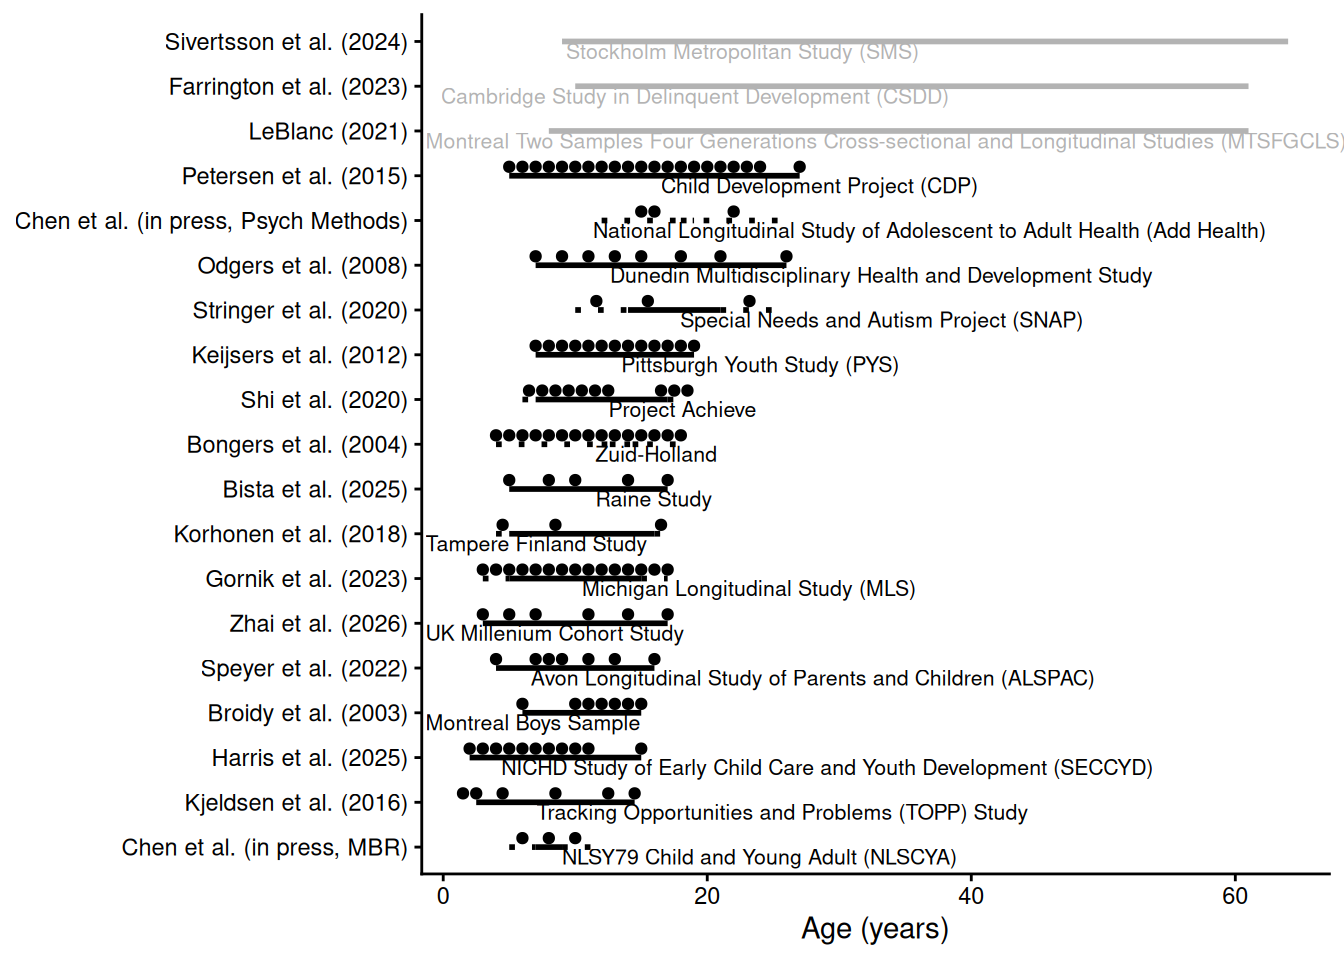

In [ ]:
#| label: fig-longitudinalexternalizingstudies
#| fig-cap: "(Approximate) ages spanned by various lengthy longitudinal studies examining individuals' trajectories of externalizing behavior. The list of longitudinal studies is not exhaustive. Studies that are based on registry data are shown in gray. Measurement occasions are depicted with solid circles. Note that, in some studies, measurement occasions only apply to a subset of participants in that study, in some cases, no participant was assessed at all measurement occasions. Solid lines reflect fully longitudinal spans (i.e., the same individuals were followed over time). Dotted lines reflect ages assessed cross-sectionally—even if some participants may have been followed longitudinally. For instance, if a study recruited 5–10-year-old children and followed each child for 20 years, the study would have dotted lines from ages 5–10 and from ages 25–30. Studies shown entirely with dotted lines assessed their full age range cross-sectionally but still included longitudinal follow-up of participants."
#| fig-alt: "(Approximate) ages spanned by various lengthy longitudinal studies examining individuals' trajectories of externalizing behavior. The list of longitudinal studies is not exhaustive. Studies that are based on registry data are shown in gray. Measurement occasions are depicted with solid circles. Note that, in some studies, measurement occasions only apply to a subset of participants in that study, in some cases, no participant was assessed at all measurement occasions. Solid lines reflect fully longitudinal spans (i.e., the same individuals were followed over time). Dotted lines reflect ages assessed cross-sectionally—even if some participants may have been followed longitudinally. For instance, if a study recruited 5–10-year-old children and followed each child for 20 years, the study would have dotted lines from ages 5–10 and from ages 25–30. Studies shown entirely with dotted lines assessed their full age range cross-sectionally but still included longitudinal follow-up of participants."

plot_longitudinalExternalizingStudies <- ggplot(
  longitudinalExternalizingStudies_plotData,
  aes(y = studyLabelFactor)
) +
  geom_segment(
    aes(
      x = ageStart,
      xend = ageEnd,
      yend = studyLabelFactor,
      linetype = segment_group,
      color = registry
    ),
    linewidth = 1
  ) +
  scale_linetype_manual(
    values = c(
      "cross-section" = "dotted",
      "core" = "solid"
    ),
    guide = "none"
  ) +
  scale_color_manual(
    values = c(
      "TRUE" = "gray70",
      "FALSE" = "black"
    ),
    guide = "none"
  ) +
  geom_point(
    data = longitudinalExternalizingStudies_measurementOccasions,
    aes(
      x = measurementOccasions,
      y = y,
      color = registry
    ),
    size = 1.5
  ) +
  ggrepel::geom_text_repel(
    data = longitudinalExternalizingStudies_sampleLabels,
    aes(
      x = label_x,
      y = label_y,
      label = sampleLabel,
      color = registry
    ),
    size = 2.8,
    nudge_y = -0.4,
    direction = "x",
    hjust = 0.5,
    vjust = 0,
    segment.color = NA,
    box.padding = 0.1,
    force = 0.5
  ) +
  coord_cartesian(clip = "off") +
  labs(
    x = "Age (years)",
    y = NULL
  ) +
  theme_classic()

plot_longitudinalExternalizingStudies

# Session Info

In [ ]:
sessionInfo()

R version 4.6.0 (2026-04-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 24.04.4 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggrepel_0.9.8     lubridate_1.9.5   forcats_1.0.1     stringr_1.6.0    
 [5] dplyr_1.2.1       purrr_1.2.2       readr_2.2.0       tidyr_1.3.2      
 [9] tibble_3.3.1      ggplot2_4.0.3     tidyverse_2.0.0   petersenlab_1.2.3

loaded vi

## Rstudio Version

In [ ]:
#rstudioapi::versionInfo()